# Prédiction des salaires

## Objectif

Cette étape construit un modèle simple pour estimer le salaire annuel d'une offre à partir de :

- la catégorie de métier ;
- la zone géographique ;
- le type de contrat ;
- l'expérience demandée ;
- les compétences techniques détectées.

L'objectif est exploratoire. Le nombre d'offres affichant un salaire reste limité, ce qui ne permet pas de construire un outil de prédiction destiné à la production.

## 1. Imports

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Chargement des données

In [7]:
DATA_PATH = Path("offres_emploi_tech_skills.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Le fichier offres_emploi_tech_skills.csv est introuvable."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

required_columns = {
    "id",
    "categorie_metier",
    "competences",
    "salaire_moy",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    missing_list = ", ".join(sorted(missing_columns))
    raise ValueError(f"Colonnes manquantes : {missing_list}")

print(f"Dimensions initiales : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions initiales : 922 lignes × 23 colonnes


,id,titre,description,type_contrat,experience,ville,secteur,entreprise,salaire_min,salaire_max,...,salaire_moy_avant_correction,salaire_corrige_heuristique,departement,ville_clean,contrat_simplifie,zone_geographique,categorie_metier,source_classification,nombre_competences,competences
0,210LQML,Chef de projet informatique DATA (H/F),Rattaché(e) au Directeur du service informatiq...,CDI,1 An(s) - Sur poste similaire,55 - BRAS-SUR-MEUSE,Commerce de gros (commerce interentreprises) d...,EMC2,NaN,NaN,...,NaN,False,55.0,BRAS-SUR-MEUSE,CDI,BRAS-SUR-MEUSE,Data Project / Product,titre,4,ETL / ELT | Machine Learning | Qlik | SQL
1,210LNTS,Data manager (F/H),En intégrant une communauté d'experts passionn...,CDI,3 An(s),31 - Toulouse,Activités des agences de travail temporaire,RANDSTAD PROFESSIONAL,40000.0,0.0,...,20000.0,True,31.0,Toulouse,CDI,Toulouse Métropole,Data Management / Governance,titre,13,Airflow | CI/CD | ETL / ELT | FastAPI | Git | ...
2,210LGWN,Data engineer (BI) - H/F/X (H/F),Nous recherchons un(e) Data Engineer passionné...,CDI,4 An(s),93 - ST DENIS,Vente à distance sur catalogue général,VENTE PRIVEE.COM,NaN,NaN,...,NaN,False,93.0,ST DENIS,CDI,Île-de-France,Data Engineer,titre,12,API REST | Airflow | BigQuery | CI/CD | Data W...
3,210LDDF,Consultant BI / Décisionnel (H/F),Vous souhaitez rejoindre un environnement où l...,CDI,4 An(s),84 - Avignon,Conseil pour les affaires et autres conseils d...,GROUPAGORA,40000.0,0.0,...,20000.0,True,84.0,Avignon,CDI,Avignon,Data Analyst / BI,titre,3,ETL / ELT | Oracle | SQL
4,210LCDC,Chargé de projet data analyst (H/F),Chargé(e) de Projets / Data Analyst (CDD) - Pa...,CDD - 6 Mois,2 An(s),75 - PARIS,Commerce de gros (commerce interentreprises) d...,REXEL FRANCE,35000.0,0.0,...,17500.0,True,75.0,Paris,CDD,Île-de-France,Data Analyst / BI,titre,3,Power BI | Qlik | SQL


## 3. Préparation de la cible

In [10]:
TARGET_COLUMN = "salaire_moy"

model_df = df.copy()
model_df[TARGET_COLUMN] = pd.to_numeric(
    model_df[TARGET_COLUMN],
    errors="coerce",
)

model_df = model_df.dropna(subset=[TARGET_COLUMN]).copy()
model_df = model_df[
    model_df[TARGET_COLUMN].between(20_000, 100_000)
].copy()

print(f"Offres avec salaire exploitable : {len(model_df):,}")
print(f"Salaire médian : {model_df[TARGET_COLUMN].median():,.0f} €")
print(f"Salaire moyen : {model_df[TARGET_COLUMN].mean():,.0f} €")

Offres avec salaire exploitable : 188
Salaire médian : 45,000 €
Salaire moyen : 44,625 €


## 4. Préparation des variables

In [13]:
CATEGORICAL_COLUMNS = [
    column
    for column in [
        "categorie_metier",
        "zone_geographique",
        "contrat_simplifie",
        "experience",
    ]
    if column in model_df.columns
]


def parse_skills(value):
    if pd.isna(value) or not str(value).strip():
        return []

    return [
        skill.strip()
        for skill in str(value).split("|")
        if skill.strip()
    ]


def group_rare_categories(series, minimum_count=5):
    cleaned_series = series.fillna("Non renseigné").astype(str)
    category_counts = cleaned_series.value_counts()
    frequent_categories = category_counts[
        category_counts >= minimum_count
    ].index

    return cleaned_series.where(
        cleaned_series.isin(frequent_categories),
        "Autre",
    )


model_df["competences_liste"] = (
    model_df["competences"].apply(parse_skills)
)

for column in CATEGORICAL_COLUMNS:
    model_df[column] = group_rare_categories(model_df[column])

skill_counts = (
    model_df[["id", "competences_liste"]]
    .explode("competences_liste")
    .dropna(subset=["competences_liste"])
    .groupby("competences_liste")["id"]
    .nunique()
    .sort_values(ascending=False)
)

MINIMUM_SKILL_FREQUENCY = 5

selected_skills = skill_counts[
    skill_counts >= MINIMUM_SKILL_FREQUENCY
].index.tolist()

for skill in selected_skills:
    column_name = f"competence__{skill}"
    model_df[column_name] = model_df["competences_liste"].apply(
        lambda skills: int(skill in skills)
    )

print(f"Variables catégorielles : {len(CATEGORICAL_COLUMNS)}")
print(f"Compétences conservées : {len(selected_skills)}")

Variables catégorielles : 4
Compétences conservées : 43


## 5. Construction de la matrice d'apprentissage

In [16]:
skill_columns = [
    f"competence__{skill}"
    for skill in selected_skills
]

categorical_features = pd.get_dummies(
    model_df[CATEGORICAL_COLUMNS],
    prefix=CATEGORICAL_COLUMNS,
    dtype=int,
)

skill_features = model_df[skill_columns].astype(int)

X = pd.concat(
    [
        categorical_features,
        skill_features,
    ],
    axis=1,
)

y = model_df[TARGET_COLUMN]

print(f"Nombre d'observations : {X.shape[0]:,}")
print(f"Nombre de variables : {X.shape[1]:,}")

Nombre d'observations : 188
Nombre de variables : 73


## 6. Séparation apprentissage et test

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print(f"Apprentissage : {len(X_train):,} offres")
print(f"Test : {len(X_test):,} offres")

Apprentissage : 150 offres
Test : 38 offres


## 7. Modèles comparés

In [22]:
models = {
    "Référence médiane": DummyRegressor(
        strategy="median"
    ),
    "Régression Ridge": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "Forêt aléatoire": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
}

cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

results = []
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    cv_scores = -cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_absolute_error",
        cv=cross_validation,
    )

    results.append(
        {
            "modele": model_name,
            "mae_test": mae,
            "rmse_test": rmse,
            "r2_test": r2,
            "mae_validation_croisee": cv_scores.mean(),
            "ecart_type_validation": cv_scores.std(),
        }
    )

    fitted_models[model_name] = model

results_df = pd.DataFrame(results).sort_values(
    "mae_validation_croisee"
).reset_index(drop=True)

results_df.round(2)

,modele,mae_test,rmse_test,r2_test,mae_validation_croisee,ecart_type_validation
0,Forêt aléatoire,7941.83,10785.10,-0.04,7881.62,1845.94
1,Régression Ridge,9332.81,12402.01,-0.38,8445.62,1651.14
2,Référence médiane,8531.16,10559.04,-0.00,8527.46,1806.79


## 8. Comparaison des performances

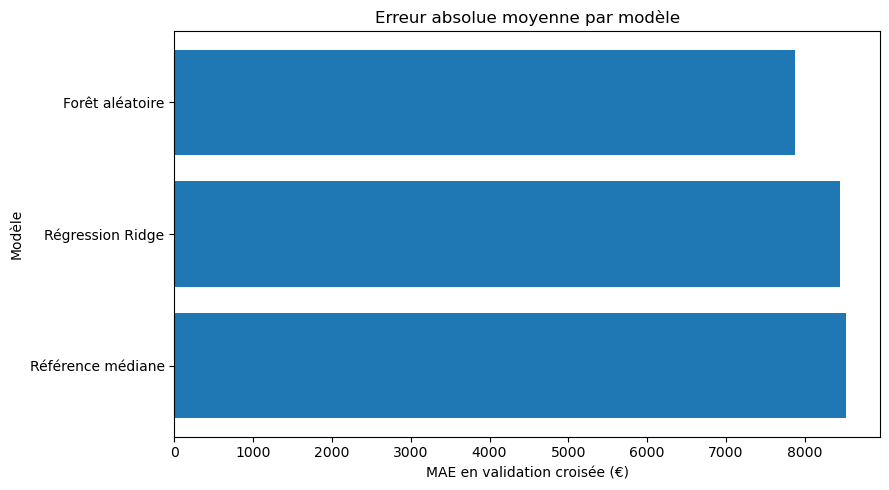

Meilleur modèle : Forêt aléatoire


In [25]:
performance_to_plot = results_df.sort_values(
    "mae_validation_croisee",
    ascending=False,
)

plt.figure(figsize=(9, 5))
plt.barh(
    performance_to_plot["modele"],
    performance_to_plot["mae_validation_croisee"],
)
plt.title("Erreur absolue moyenne par modèle")
plt.xlabel("MAE en validation croisée (€)")
plt.ylabel("Modèle")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["modele"]
best_model = fitted_models[best_model_name]

print(f"Meilleur modèle : {best_model_name}")

## 9. Valeurs réelles et prédictions

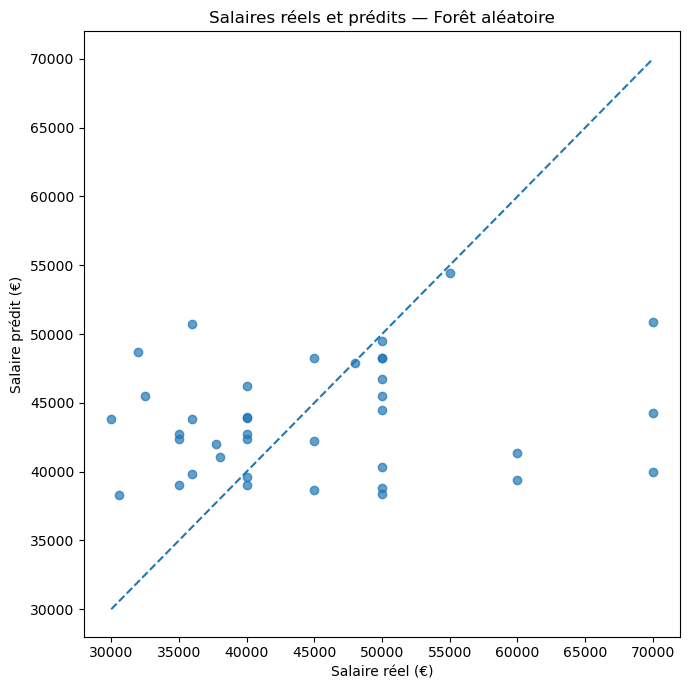

,salaire_reel,salaire_predit,erreur_absolue
903,70000.0,39958.0,30042.0
25,70000.0,44230.0,25770.0
395,60000.0,39418.0,20582.0
795,70000.0,50844.0,19156.0
681,60000.0,41367.0,18633.0
22,32000.0,48696.0,16696.0
129,36000.0,50701.0,14701.0
82,30000.0,43854.0,13854.0
126,32492.0,45501.0,13009.0
366,50000.0,38350.0,11650.0


In [28]:
best_predictions = best_model.predict(X_test)

prediction_results = pd.DataFrame(
    {
        "salaire_reel": y_test,
        "salaire_predit": best_predictions,
    }
)

prediction_results["erreur_absolue"] = (
    prediction_results["salaire_reel"]
    - prediction_results["salaire_predit"]
).abs()

minimum_salary = min(
    prediction_results["salaire_reel"].min(),
    prediction_results["salaire_predit"].min(),
)

maximum_salary = max(
    prediction_results["salaire_reel"].max(),
    prediction_results["salaire_predit"].max(),
)

plt.figure(figsize=(7, 7))
plt.scatter(
    prediction_results["salaire_reel"],
    prediction_results["salaire_predit"],
    alpha=0.7,
)
plt.plot(
    [minimum_salary, maximum_salary],
    [minimum_salary, maximum_salary],
    linestyle="--",
)
plt.title(f"Salaires réels et prédits — {best_model_name}")
plt.xlabel("Salaire réel (€)")
plt.ylabel("Salaire prédit (€)")
plt.tight_layout()
plt.show()

prediction_results.sort_values(
    "erreur_absolue",
    ascending=False,
).head(10).round(0)

## 10. Analyse des erreurs

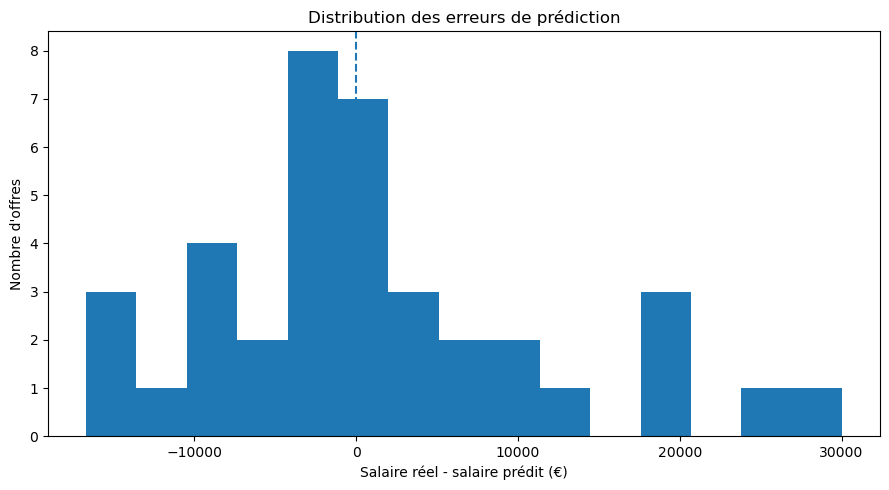

count       38.0
mean      1275.0
std      10853.0
min     -16696.0
25%      -4226.0
50%        234.0
75%       5277.0
max      30042.0
Name: residu, dtype: float64

In [31]:
prediction_results["residu"] = (
    prediction_results["salaire_reel"]
    - prediction_results["salaire_predit"]
)

plt.figure(figsize=(9, 5))
plt.hist(
    prediction_results["residu"],
    bins=15,
)
plt.axvline(
    0,
    linestyle="--",
)
plt.title("Distribution des erreurs de prédiction")
plt.xlabel("Salaire réel - salaire prédit (€)")
plt.ylabel("Nombre d'offres")
plt.tight_layout()
plt.show()

prediction_results["residu"].describe().round(0)

## 11. Variables les plus influentes

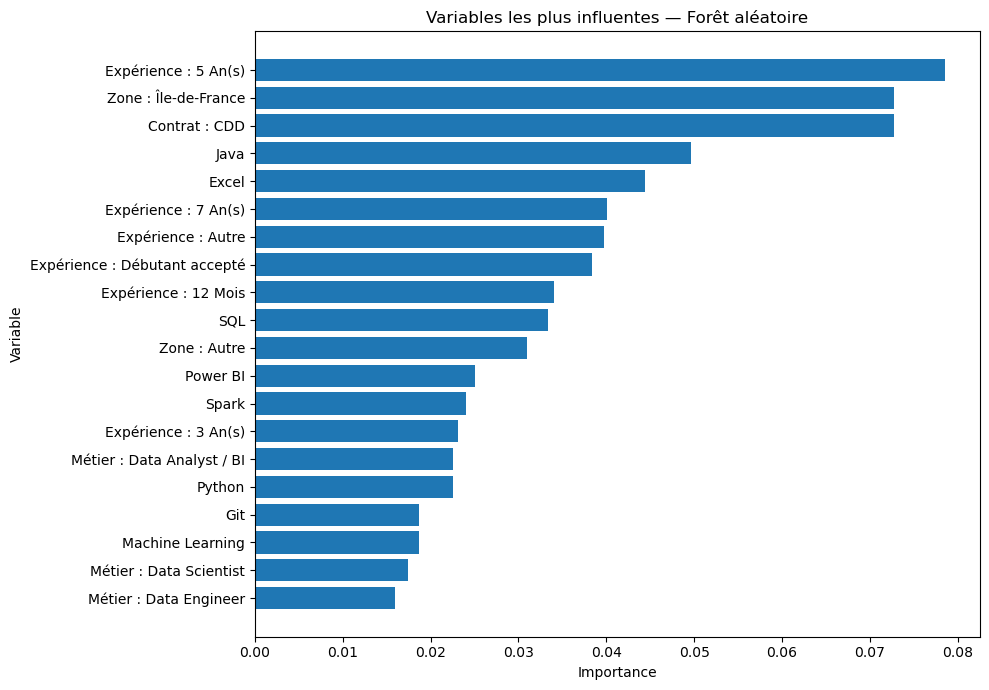

In [34]:
def clean_feature_name(feature_name):
    return (
        feature_name
        .replace("competence__", "")
        .replace("categorie_metier_", "Métier : ")
        .replace("zone_geographique_", "Zone : ")
        .replace("contrat_simplifie_", "Contrat : ")
        .replace("experience_", "Expérience : ")
    )


if best_model_name == "Régression Ridge":
    coefficients = best_model.named_steps["model"].coef_
    feature_importance = pd.DataFrame(
        {
            "variable": X.columns,
            "importance": np.abs(coefficients),
            "effet": coefficients,
        }
    )

elif best_model_name == "Forêt aléatoire":
    feature_importance = pd.DataFrame(
        {
            "variable": X.columns,
            "importance": best_model.feature_importances_,
            "effet": np.nan,
        }
    )

else:
    feature_importance = pd.DataFrame(
        columns=["variable", "importance", "effet"]
    )

if feature_importance.empty:
    print("Le modèle de référence ne fournit pas d'importance de variables.")
else:
    feature_importance["variable_affichee"] = (
        feature_importance["variable"].apply(clean_feature_name)
    )

    top_features = (
        feature_importance
        .sort_values("importance", ascending=False)
        .head(20)
        .sort_values("importance")
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_features["variable_affichee"],
        top_features["importance"],
    )
    plt.title(f"Variables les plus influentes — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

    display_columns = [
        "variable_affichee",
        "importance",
        "effet",
    ]

    top_features[
        display_columns
    ].sort_values(
        "importance",
        ascending=False,
    ).reset_index(drop=True)

## 12. Export des résultats

In [37]:
METRICS_PATH = Path("resultats_modeles_salaires.csv")
PREDICTIONS_PATH = Path("predictions_salaires_test.csv")
IMPORTANCE_PATH = Path("importance_variables_salaires.csv")

results_df.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

prediction_results.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

if not feature_importance.empty:
    feature_importance.to_csv(
        IMPORTANCE_PATH,
        index=False,
        encoding="utf-8-sig",
    )

print(f"Métriques : {METRICS_PATH}")
print(f"Prédictions : {PREDICTIONS_PATH}")

if not feature_importance.empty:
    print(f"Importance des variables : {IMPORTANCE_PATH}")

Métriques : resultats_modeles_salaires.csv
Prédictions : predictions_salaires_test.csv
Importance des variables : importance_variables_salaires.csv


## Conclusion

Le modèle est comparé à une référence fondée sur le salaire médian. Une amélioration limitée par rapport à cette référence indique que les variables disponibles ne suffisent pas à expliquer précisément les salaires.

Les résultats doivent être interprétés comme une estimation exploratoire, notamment en raison :

- du faible nombre d'offres affichant un salaire ;
- de l'absence de certaines informations comme la taille de l'entreprise ;
- de la diversité des intitulés et des niveaux de séniorité ;
- de la dépendance entre compétences, métier et expérience.